# Aprendizaje No Supervizado: Clustering

Llamamos **Aprendizaje No Supervisado** a los métodos para trabajar con datos (instancias) que no tienen asociados una etiqueta (una clase o un valor).  A diferencia del Aprendizaje Supervisado, el objetivo ya no pasa por predecir la etiqueta, sino por encontrar patrones en el set de datos

Las principales herramientas en Aprendizaje No Supervisado son:
-Clustering
-Reducción de dimensionalidad

En esta guía trabajaremos con **métodos de Clustering**: Dado un set de datos, nuestro objetivo será encontrar grupos (clusters) en los cuales las instancias pertenecientes sean parecidas (estén “cerca”).

Existen muchos métodos para separar en clusters, en esta guía vamos a trabajar con los métodos K-means y DBSCAN. Además vamos a utilizar el método Elbow para determinar el número ótimo de clusters (K) en el método K-means.

**Esta guía es principalmente demostrativa, pero les dejamos algunas cositas para que completen ustedes si quieren practicar!**


**¡Comencemos!**

In [119]:
#Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Datasets con los que vamos a trabajar:

Para empezar, vamos a generarnos una serie de datasets sintéticos con las funciones que ya vienen incorporadas en Scikit-learn. Notemos que estos datos vienen con una etiqueta asociada donde nos indica a qué cluster pertenecen. La idea será utilizar los métodos de clustering estudiados para poder identificar los clusters sin conocer esta etiqueta.

In [120]:
from sklearn.datasets import make_blobs, make_moons

X1, y1 = make_blobs(n_samples=1000, centers=4, cluster_std=0.5, n_features=2, random_state=0)
X2, y2 = make_blobs(n_samples=1000, centers=4, cluster_std=1, n_features=2, random_state=0)
X3, y3 = make_moons(n_samples=1000, noise=.05, random_state=0)

Grafiquemos los datasets para ver las diferencias entre cada uno.

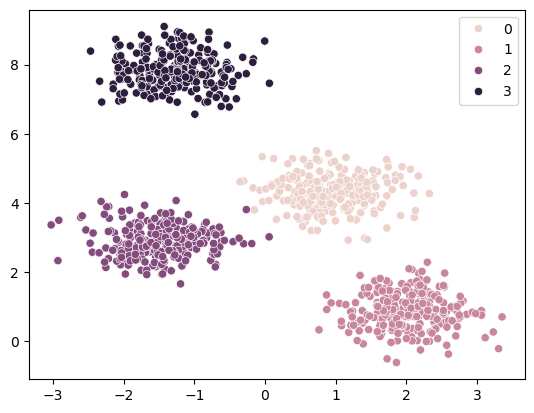

In [121]:
sns.scatterplot(x = X1[:,0], y = X1[:,1], hue = y1)
plt.show()

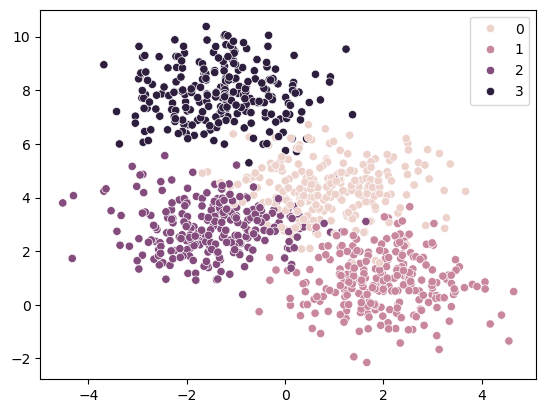

In [122]:
sns.scatterplot(x = X2[:,0], y = X2[:,1], hue = y2)
plt.show()

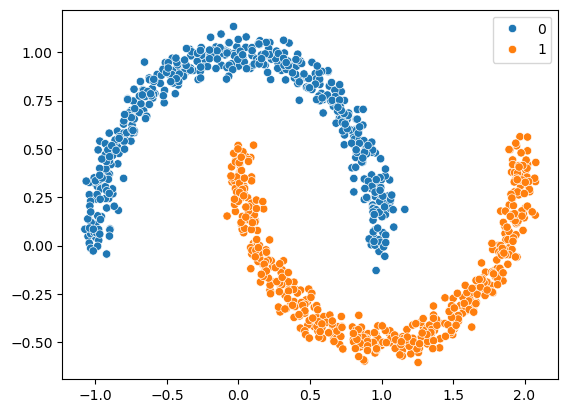

In [123]:
sns.scatterplot(x = X3[:,0], y = X3[:,1], hue = y3)
plt.show()

 1.1 K-means

Scikit-Learn tiene una implementación de K-means.

1. Lee la documentación.

2. Define los 2 modelos para los dos datasets.

In [124]:
from sklearn.cluster import KMeans

# Especificamos el numero adecuado de clusters en cada caso
kmeans_1 = KMeans(n_clusters=4, random_state=0)
kmeans_2 = KMeans(n_clusters=4, random_state=0)
kmeans_3 = KMeans(n_clusters=2, random_state=0)

3. Entrena los modelos con los datos, recuerda que NO hay que pasarles las etiquetas, solo los atributos.

In [125]:
kmeans_1.fit(X1)
kmeans_2.fit(X2)
kmeans_3.fit(X3)

KMeans(n_clusters=2, random_state=0)

Luego de entrenar los modelos, podemos consultar las etiquetas que se le asignó a cada instancia y el lugar de los centroides.

In [126]:
etiquetas_1 = kmeans_1.labels_
print(etiquetas_1)

[1 3 1 0 2 3 3 2 3 3 1 2 0 1 2 0 0 1 3 2 3 1 2 2 2 0 2 2 2 0 2 3 1 0 1 3 1
 3 0 0 3 3 3 0 1 3 3 1 0 3 2 3 3 0 1 2 3 3 1 1 2 2 0 0 0 1 3 0 1 1 1 1 1 0
 3 1 3 1 0 2 3 3 3 0 2 3 3 3 0 0 1 0 0 1 1 1 0 0 3 3 2 0 3 2 3 0 3 1 0 2 3
 3 0 1 0 0 3 0 2 2 2 1 0 0 3 2 3 1 0 2 2 3 0 3 3 3 0 3 2 1 2 1 2 3 1 1 2 3
 1 1 2 3 3 3 0 3 3 3 2 0 1 2 3 3 3 3 1 1 3 2 0 2 2 2 0 2 0 2 2 3 0 3 0 3 3
 0 2 0 2 1 0 3 2 2 0 1 0 1 0 0 0 3 1 1 2 2 0 3 1 3 1 0 3 1 0 3 3 2 2 1 3 3
 3 1 3 3 3 0 1 1 3 0 3 3 0 2 0 2 2 0 3 0 2 2 1 1 1 1 1 1 3 0 1 0 0 2 0 3 1
 3 2 1 3 2 1 0 3 0 1 2 2 3 2 0 1 1 0 1 0 3 2 1 0 3 0 0 0 3 0 1 2 0 3 1 1 2
 1 2 3 1 2 1 1 0 0 1 3 3 2 3 3 3 1 2 0 3 0 2 3 1 3 1 2 0 0 3 1 2 1 2 1 2 1
 0 0 1 2 3 2 3 0 3 1 3 2 2 2 2 2 2 0 2 0 2 3 1 2 1 1 3 3 3 3 1 1 0 1 1 1 3
 1 2 0 1 0 2 0 3 1 1 1 3 0 2 2 2 1 1 0 1 2 1 2 1 0 1 1 2 2 3 1 0 1 0 0 2 3
 3 3 1 0 3 0 0 0 3 3 1 2 1 3 0 0 0 1 3 1 1 3 3 0 2 0 1 1 3 0 3 2 1 2 1 1 0
 0 3 2 3 3 3 0 1 3 0 1 2 0 2 1 2 3 2 3 1 1 2 0 1 1 2 3 0 3 3 3 3 3 2 0 3 0
 3 2 3 1 0 0 1 1 1 1 2 0 

In [127]:
centros_1 = kmeans_1.cluster_centers_
print(centros_1)

[[-1.49807428  2.90164881]
 [-1.27283855  7.84651464]
 [ 2.01942692  0.87474842]
 [ 0.92917513  4.29023124]]


In [128]:
etiquetas_2 = kmeans_2.labels_
centros_2 = kmeans_2.cluster_centers_
etiquetas_3 = kmeans_3.labels_
centros_3 = kmeans_3.cluster_centers_

4.  Ploteamos los resultados para todos los datasets. ¿Les parece que la separación fue adecuada?

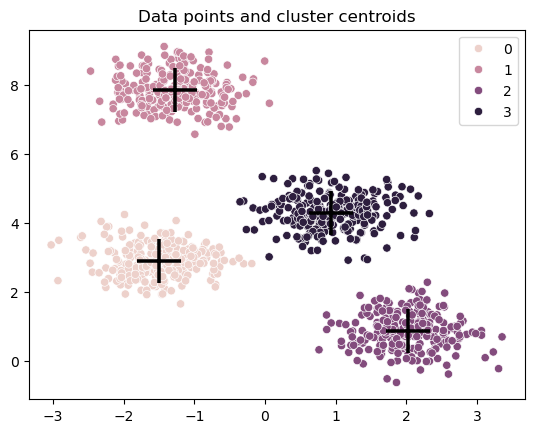

In [129]:
sns.scatterplot(x = X1[:,0], y = X1[:,1], hue = etiquetas_1)
sns.scatterplot(x = centros_1[:, 0], y = centros_1[:, 1],color='black', marker="+", s=1000)
plt.title('Data points and cluster centroids')
plt.show()

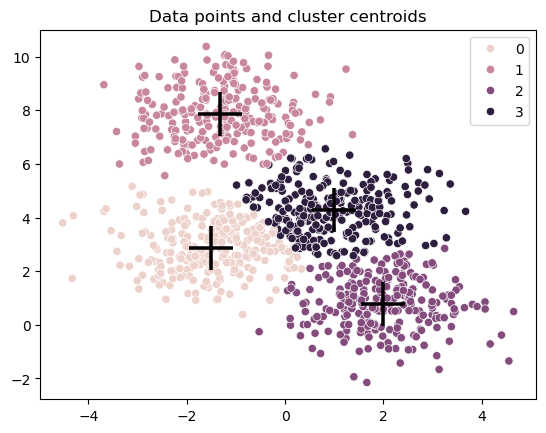

In [130]:
sns.scatterplot(x = X2[:, 0], y =X2[:, 1], hue = etiquetas_2)
sns.scatterplot(x = centros_2[:, 0], y =centros_2[:, 1],color='black', marker="+", s=1000)
plt.title('Data points and cluster centroids')
plt.show()

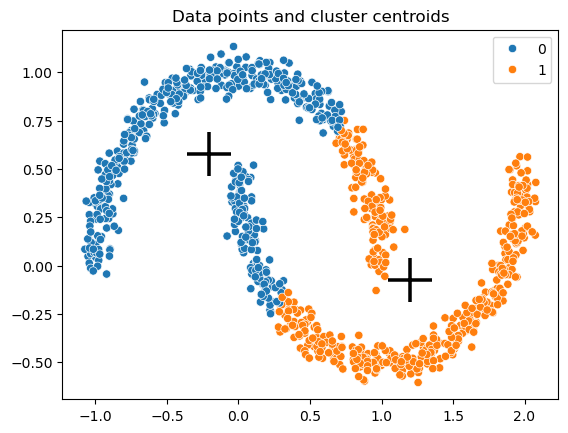

In [131]:
sns.scatterplot(x = X3[:, 0], y =X3[:, 1], hue = etiquetas_3)
sns.scatterplot(x = centros_3[:, 0], y = centros_3[:, 1],color='black', marker="+", s=1000)
plt.title('Data points and cluster centroids')
plt.show()

5. Podemos trazar la frontera de decisiones del modelo. Esto nos da diagramas de Voronoi.

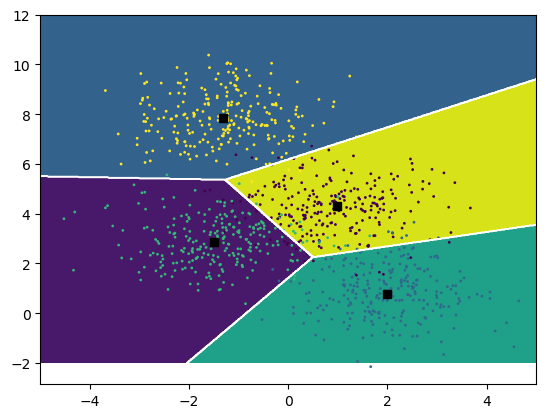

In [132]:
k = 4
#my_init = np.array([[1,1],[2,2],[3,3],[4,4],[5,5]])
#my_init = np.array([[-2,8],[-1,6],[0,4],[1,2],[2,0]])
kmeans_2 = KMeans(n_clusters=k, random_state=0)
#kmeans_2 = KMeans(n_clusters=k, init=my_init, n_init=1)
kmeans_2.fit(X2) 

x0_grid = np.linspace(-5, 5, 500)
x1_grid = np.linspace(-2, 12, 600)
m0, m1 = np.meshgrid(x0_grid, x1_grid)
y_grid = kmeans_2.predict(np.c_[m0.flatten(), m1.flatten()])

plt.contourf(m0, m1, y_grid.reshape(m0.shape))
plt.contour(m0, m1, y_grid.reshape(m0.shape), linewidths=1, colors='white')
plt.scatter(X2[:,0], X2[:,1], c=y2, s=1)
plt.scatter(kmeans_2.cluster_centers_[:,0], kmeans_2.cluster_centers_[:,1],
            marker='s', c='black' )

**Ejercicio**: a) Obtener nuevamente las coordenadas de los centroides de los clusters especificando inicialmente el número de clusters en 3 y en 5. Representar los centroides y las fronteras de decisión para los modelos K-means con k=3 y k=5.
b) Inicializar los centroides para k=5 con las listas propuestas. Notar como cambian los trazados para las fronteras de deciones. c) Repetir la construcción de la frontera de decisiones para los otros conjuntos de datos.

## Distancia al centroide

Vamos a evaluar las particiones que realizamos mediante KMeans usando la distancia al centroide. La idea es que al variar el número de clúster K en el modelo, el valor de la distancia media de los datos al centroide más cercano va a variar. Queremos graficar esa curva para elegir el número de particiones óptimos con el metodo del codo.

Preparamos una lista con las distancias medias a los centroides en el dataset 1. Vamos a probar un número de clústers que va de 2 a 14.

In [133]:
# Preparamos una lista donde vamos a ir agregando las distancias medias
Sum_of_squared_distances = []
# Fiteammos un modelo para cada numero de cluster que queremos testear
K = np.arange(2,14)
for k in K:
    # Definimos y entrenamos el modelo
    km = KMeans(n_clusters=k)
    km = km.fit(X1)
    # Calculamos la distancia media y agregamos a la lista
    distancia_total = km.inertia_
    distancia_media = np.divide(distancia_total,X1.shape[0])
    Sum_of_squared_distances.append(distancia_media)

Graficamos la distancia media en función del núemro de clústers.

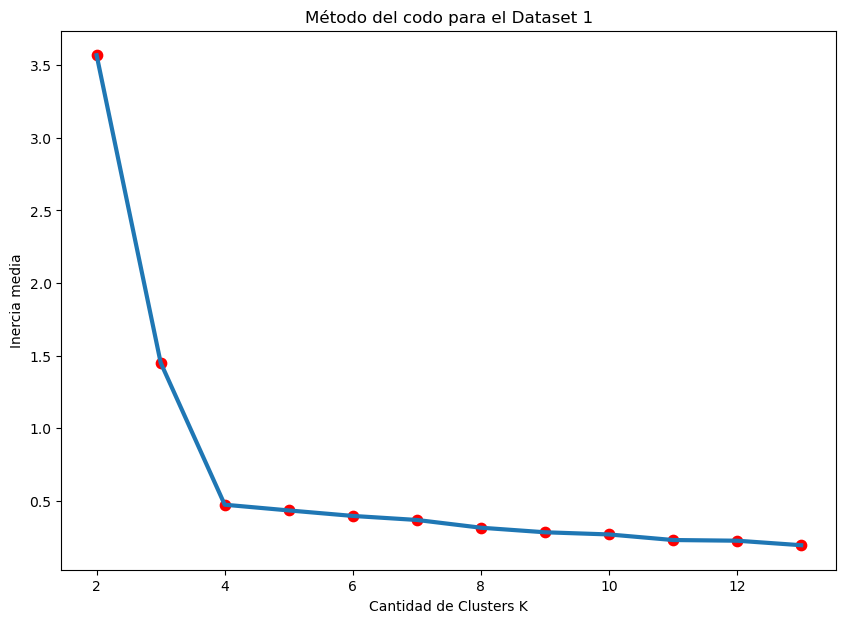

In [134]:
plt.figure(figsize = (10,7))
plt.plot(K, Sum_of_squared_distances, lw=3)
plt.scatter(K, Sum_of_squared_distances,s=55,c='r')
plt.xlabel('Cantidad de Clusters K')
plt.ylabel('Inercia media')
plt.title('Método del codo para el Dataset 1')

plt.show()

Repita el gráfico, pero esta vez para los datasets 2 y 3. Recomendamos copiar el código anterior y modificarlo.

Usar el criterio para elegir el mejor numero de k en cada caso según la curva y graficar los clusters para cada dataset. Fijense que 4 Corresponde al número de clusters optimos que se observan a simple vista para el primer dataset.


# DBSCAN

1. Lee la documentación.
2. Define los 3 modelos para los distintos datasets.

In [135]:
from sklearn.cluster import DBSCAN

# En este paso tenemos que definir el epsilon y en min_samples, los parametros del método.
db_1 = DBSCAN(eps=0.3, min_samples=10)
db_2 = DBSCAN(eps=0.4, min_samples=12)
db_3 = DBSCAN(eps=0.2, min_samples=10)

3. Entrena los modelos con los distintos datasets

In [136]:
db_1.fit(X1)
db_2.fit(X2)
db_3.fit(X3)

DBSCAN(eps=0.2, min_samples=10)

Podemos consultar las etiquetas asignadas luego de entrenar en la variable `labels_`. Notemos que cuando el label sea igual a '-1' quiere decir que esa instancia fue considerada ruido.

4. Teniendo en cuenta esto, podemos obtener el numero de clusters y el numero de instancias consideradas ruido de la siguiente forma (solo lo hacemos para el primer dataset):

In [137]:
# Consultamos las etiquetas
labels_1 = db_1.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_1 = len(set(labels_1)) - (1 if -1 in labels_1 else 0)
n_noise_1 = list(labels_1).count(-1)

In [138]:
print('Estimated number of clusters: %d' % n_clusters_1)
print('Estimated number of noise points: %d' % n_noise_1)

Estimated number of clusters: 4
Estimated number of noise points: 64


Les damos ya definida una función que plotea los resultados de manera tal que colorea con distintos colores los distintos clusters, en gris los datos que se consideran Noise y ademas en tamaño mas grande las instancias que son CORES. No hace falta que cambien nada de esta función.

In [139]:
# Funcion para plotear, NO CAMBIAR NADA
def plot_DBSCAN(X1,labels_1,db_1,n_clusters_1):
    # Armamos una mascara, con unos en los datos que son CORES.
    core_samples_mask_1 = np.zeros_like(db_1.labels_, dtype=bool)
    core_samples_mask_1[db_1.core_sample_indices_] = True
    # Plot result

    # Black removed and is used for noise instead.
    unique_labels = set(labels_1)
    colors = [plt.cm.Spectral(each)
              for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]

        class_member_mask = (labels_1 == k)

        xy = X1[class_member_mask & core_samples_mask_1]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=14)

        xy = X1[class_member_mask & ~core_samples_mask_1]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=6)
    plt.title('Estimated number of clusters: %d' % n_clusters_1)
    plt.show()
    return

5. Ploteamos el resultado para el primer caso. ¿Te parece adecuado el resultado? Prueba qué pasa si modifica los parámetros de epsilon y min_dist.

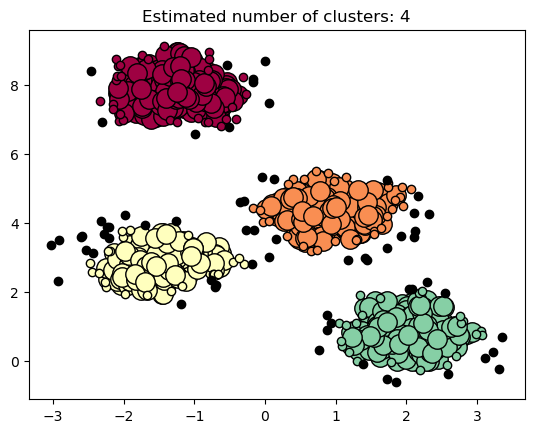

In [140]:
plot_DBSCAN(X1,labels_1,db_1,n_clusters_1)

6. Repetimos el paso 5 para los otros 2 datasets, nota que debe calcular `labels_2`, `core_samples_mask_2`, etc... Recomendación: vuelva a copiar todo el codigo en las siguientes celdas en lugar de modificar el que ya tiene escrito para el dataset 1.

Estimated number of clusters: 4
Estimated number of noise points: 64


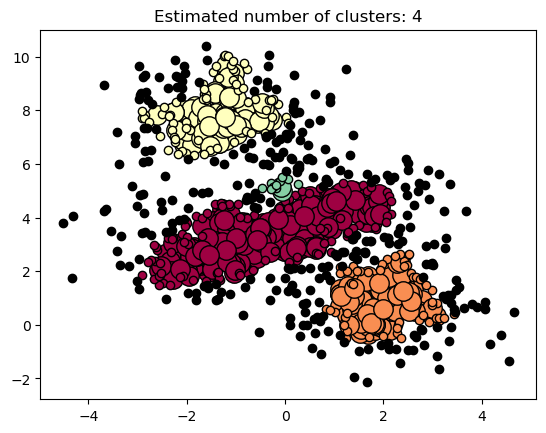

In [141]:
# Consultamos las etiquetas
labels_2 = db_2.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_2 = len(set(labels_2)) - (1 if -1 in labels_2 else 0)
n_noise_2 = list(labels_2).count(-1)

print('Estimated number of clusters: %d' % n_clusters_1)
print('Estimated number of noise points: %d' % n_noise_1)

# Armamos una mascara, con unos en los datos que son CORES.
core_samples_mask_2 = np.zeros_like(db_2.labels_, dtype=bool)
core_samples_mask_2[db_2.core_sample_indices_] = True

plot_DBSCAN(X2,labels_2,db_2,n_clusters_2)

Estimated number of clusters: 2
Estimated number of noise points: 0


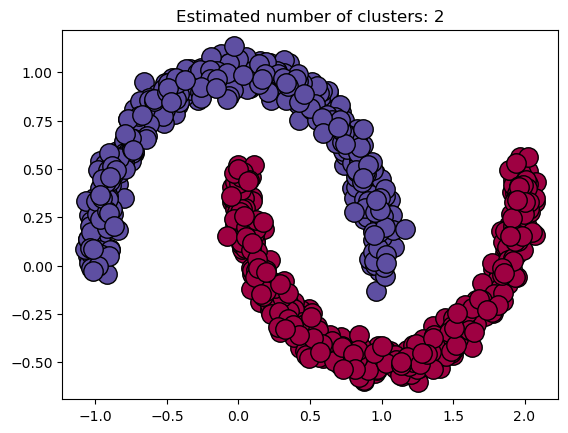

In [142]:
# Consultamos las etiquetas
labels_3 = db_3.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_3 = len(set(labels_3)) - (1 if -1 in labels_3 else 0)
n_noise_3 = list(labels_3).count(-1)

print('Estimated number of clusters: %d' % n_clusters_3)
print('Estimated number of noise points: %d' % n_noise_3)

# Armamos una mascara, con unos en los datos que son CORES.
core_samples_mask_3 = np.zeros_like(db_2.labels_, dtype=bool)
core_samples_mask_3[db_2.core_sample_indices_] = True

plot_DBSCAN(X3,labels_3,db_3,n_clusters_3)